# Bank-App Session Signal Explorer

Visual review of exported **Prototype 2 bank-app** session JSON (`participantId_sNNN_sessionId.json`).

Purpose is the same as the old audit explorer: load a session and look at the raw signal graphs by eye to spot anything interesting (flat/constant fields, dropouts, saturation, odd shapes). This is **not** a feature/windowing pipeline.

In [1]:
from pathlib import Path
import json, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 160)

COLORS = {
    "x": "#2563EB", "dx": "#2563EB", "ax": "#2563EB", "agx": "#2563EB", "alpha": "#2563EB", "rotAlpha": "#2563EB",
    "y": "#DC2626", "dy": "#DC2626", "ay": "#DC2626", "agy": "#DC2626", "beta": "#DC2626", "rotBeta": "#DC2626",
    "z": "#16A34A", "az": "#16A34A", "agz": "#16A34A", "gamma": "#16A34A", "rotGamma": "#16A34A",
    "scrollLeft": "#DC2626", "scrollTop": "#2563EB", "scrollTopRatio": "#7C3AED", "maxScrollLeft": "#0891B2",
    "force": "#6B7280", "radiusX": "#2563EB", "radiusY": "#DC2626", "rotationAngle": "#7C3AED",
    "touchesCount": "#F59E0B", "pressure": "#6B7280", "width": "#7C3AED", "height": "#F59E0B",
    "movementX": "#2563EB", "movementY": "#DC2626",
    "valueLength": "#2563EB", "deltaLength": "#DC2626", "dataLength": "#F59E0B",
    "selectionStart": "#16A34A", "selectionEnd": "#7C3AED",
    "viewportWidth": "#2563EB", "viewportHeight": "#DC2626", "scale": "#7C3AED", "interval": "#6B7280",
    "distancePx": "#2563EB", "durationMs": "#DC2626", "swipeRatio": "#7C3AED",
}
DEFAULT_COLOR, TEXT, MUTED, GRID, BG = "#374151", "#111827", "#6B7280", "#E5E7EB", "white"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "axes.edgecolor": "#D1D5DB", "axes.labelcolor": TEXT, "xtick.color": TEXT, "ytick.color": TEXT,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "grid.alpha": 0.7, "font.size": 10,
})

def field_color(f): return COLORS.get(f, DEFAULT_COLOR)

def polish_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D1D5DB")
    ax.spines["bottom"].set_color("#D1D5DB")
    ax.grid(axis="y", color=GRID, alpha=0.7)
    ax.grid(axis="x", color=GRID, alpha=0.35)
    return ax


## Load data

Put your exported session JSON in `./data/raw_json/` (or `./data/`, or next to this notebook), or set `FILES` to an explicit list of paths. Multiple files are fine; the time-series plots use one `FOCUS_SESSION` at a time so traces don't get mixed together.

In [2]:
CANDIDATE_DIRS = [Path("data/raw_json"), Path("data"), Path(".")]
FILES = None   # e.g. [Path("pG5G4MS_s041_xxx.json")] to pick specific files

def find_session_files():
    if FILES:
        return [Path(p) for p in FILES]
    for d in CANDIDATE_DIRS:
        if d.exists():
            found = sorted(d.glob("*.json"))
            if found:
                return found
    return []

def is_bank_session(obj):
    return isinstance(obj, dict) and "events" in obj and "taskSummary" in obj and "fieldSummary" not in obj

def flatten_events(obj, skey):
    rows = []
    for e in obj.get("events", []):
        row = {k: v for k, v in e.items() if k != "payload"}
        row.update(e.get("payload") or {})
        row["sessionKey"] = skey
        rows.append(row)
    return rows

paths = find_session_files()
event_rows, session_rows, task_rows = [], [], []
for p in paths:
    try:
        obj = json.load(open(p))
    except Exception as ex:
        print("Skip", p.name, "->", ex); continue
    if not is_bank_session(obj):
        print("Skip", p.name, "-> not a bank-app session (no taskSummary / looks like audit data)"); continue
    skey = "{}_s{}".format(obj.get("participantId"), obj.get("sessionIndex"))
    event_rows += flatten_events(obj, skey)
    qs = obj.get("qualitySummary", {}) or {}
    ctx = obj.get("context", {}) or {}
    dev = obj.get("device", {}) or {}
    perms = obj.get("permissions", {}) or {}
    session_rows.append({
        "sessionKey": skey, "file": p.name,
        "participantId": obj.get("participantId"), "sessionIndex": obj.get("sessionIndex"),
        "appMode": obj.get("appMode"), "durationS": round((obj.get("sessionDurationMs") or 0) / 1000, 1),
        "events": len(obj.get("events", [])), "tasks": len(obj.get("taskSummary", [])),
        "completedNormally": obj.get("completedNormally"),
        "usable": qs.get("usableForSignalExtraction"), "warnings": qs.get("warnings"),
        "devicePlatform": ctx.get("devicePlatform"), "deviceModel": ctx.get("deviceModel"),
        "deviceFamily": dev.get("deviceFamily"), "platform": dev.get("platform"),
        "motionPerm": perms.get("motion"), "orientationPerm": perms.get("orientation"),
        "ua": (dev.get("userAgent") or "")[:55],
    })
    for t in obj.get("taskSummary", []):
        task_rows.append({"sessionKey": skey, **t})

events_df = pd.DataFrame(event_rows)
sessions_df = pd.DataFrame(session_rows)
tasks_df = pd.DataFrame(task_rows)

if events_df.empty:
    print("No bank-app session JSON found. Put *.json in ./data/raw_json (or set FILES) and re-run.")
    FOCUS_SESSION = None
    fdf = pd.DataFrame(columns=["kind", "tRelMs", "activeArea"])
else:
    print("Loaded {} session(s), {} events".format(len(sessions_df), len(events_df)))
    print("Sessions available:", list(sessions_df["sessionKey"]))
    FOCUS_SESSION = sessions_df["sessionKey"].iloc[0]
    fdf = events_df[events_df["sessionKey"] == FOCUS_SESSION].copy()
    print("FOCUS_SESSION =", FOCUS_SESSION, "(edit this var + re-run cells below to switch)")


Loaded 1 session(s), 3701 events
Sessions available: ['pG5G4MS_s3']
FOCUS_SESSION = pG5G4MS_s3 (edit this var + re-run cells below to switch)


## Session overview

In [3]:
display(sessions_df)

,sessionKey,file,participantId,sessionIndex,appMode,durationS,events,tasks,completedNormally,usable,warnings,devicePlatform,deviceModel,deviceFamily,platform,motionPerm,orientationPerm,ua
0,pG5G4MS_s3,session.json,pG5G4MS,3,collection,142.1,3701,26,True,True,"[missing_motion_events, missing_orientation_events]",iphone,iphone_16_plus,mobile,iPhone,error,error,Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like Mac OS X)


## Event counts (focused session)

,kind,count
0,touchmove,1141
1,scroll,673
2,carousel_scroll,247
3,pointermove,219
4,window_scroll,141
5,keydown,126
6,beforeinput,126
7,input,126
8,keyup,126
9,pointerdown,125


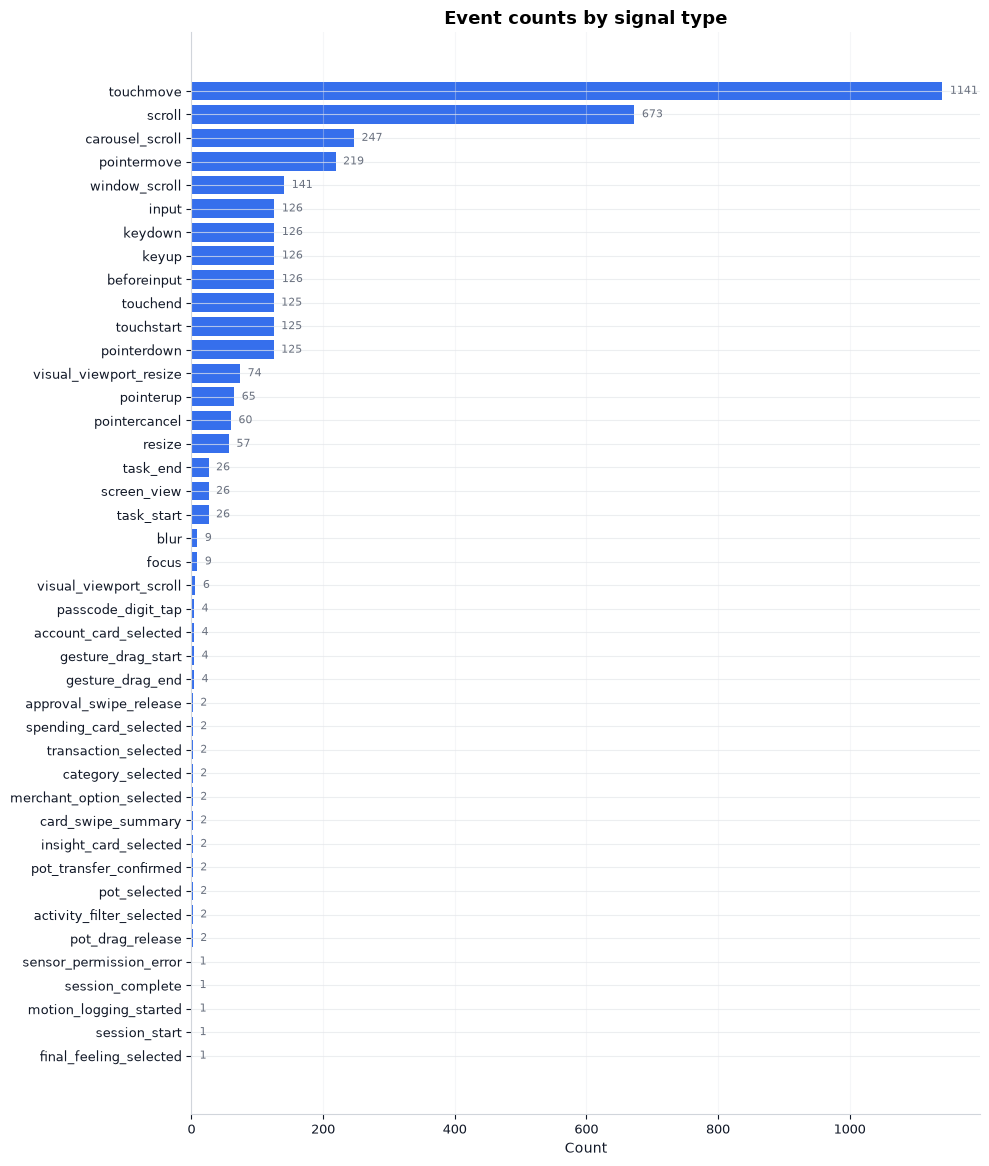

In [4]:
if fdf.empty:
    print("No events to plot.")
else:
    counts = fdf["kind"].value_counts().rename_axis("kind").reset_index(name="count")
    display(counts)
    plot_df = counts.sort_values("count", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(5, len(plot_df) * 0.28)))
    bars = ax.barh(plot_df["kind"], plot_df["count"], color="#2563EB", alpha=0.92)
    ax.set_title("Event counts by signal type")
    ax.set_xlabel("Count"); polish_ax(ax)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + max(plot_df["count"]) * 0.01, bar.get_y() + bar.get_height()/2, str(int(w)),
                va="center", ha="left", fontsize=8, color=MUTED)
    plt.tight_layout(); plt.show()

## Field availability & quality (computed from raw events)

The bank-app JSON has no precomputed `fieldSummary`, so this is derived here: per `(kind, field)` non-null fraction, unique count, and an `allZeroish` flag that catches dead constant-zero fields (e.g. iOS `radiusY` / `rotationAngle`).

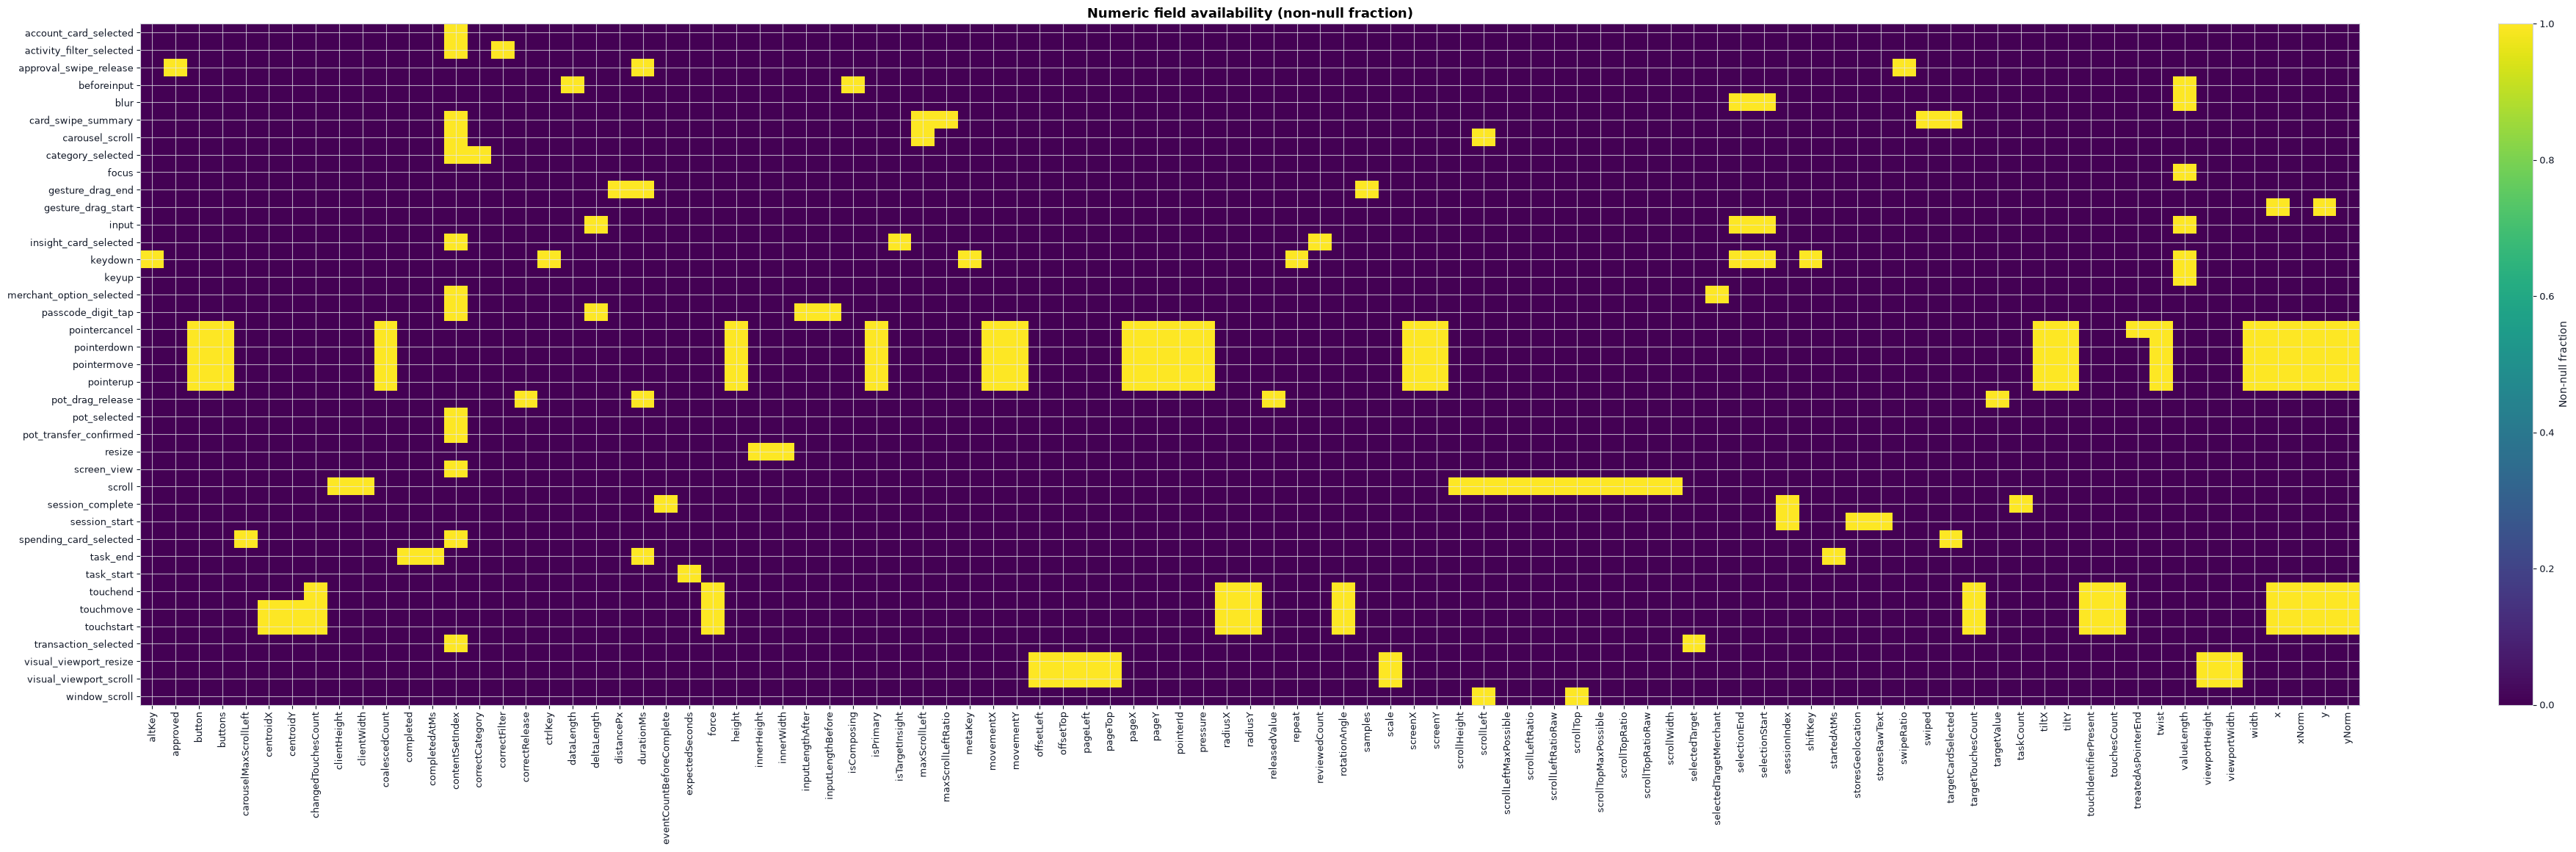

,kind,field,count,nonNullFrac,uniqueCount,allZeroish,min,max
0,account_card_selected,accountId,4,1.0,3,False,NaN,NaN
1,account_card_selected,activeArea,4,1.0,1,False,NaN,NaN
2,account_card_selected,activeBaseTaskId,4,1.0,2,False,NaN,NaN
3,account_card_selected,activeTaskId,4,1.0,2,False,NaN,NaN
4,account_card_selected,componentId,4,1.0,3,False,NaN,NaN
...,...,...,...,...,...,...,...,...
431,window_scroll,activeArea,141,1.0,5,False,NaN,NaN
432,window_scroll,screenId,141,1.0,20,False,NaN,NaN
433,window_scroll,scrollLeft,141,1.0,1,True,0.0,0.0
434,window_scroll,scrollTop,141,1.0,104,False,0.0,371.0


In [5]:
def compute_field_stats(df):
    skip = {"sessionKey", "kind", "tRelMs", "t", "ms", "tISO", "timestampIso", "taskIndex", "instructionArea"}
    rows = []
    for kind, g in df.groupby("kind"):
        n = len(g)
        for col in g.columns:
            if col in skip:
                continue
            s = g[col]
            nn = int(s.notna().sum())
            if nn == 0:
                continue
            try:
                num = pd.to_numeric(s, errors="coerce")
            except (TypeError, ValueError):
                num = pd.Series(np.nan, index=s.index)
            is_num = int(num.notna().sum()) > 0
            allzero = bool(is_num and np.nanmax(np.abs(num.dropna().values)) < 1e-9) if is_num else False
            try:
                uniq = int(s.nunique(dropna=True))
            except TypeError:
                uniq = int(s.dropna().map(lambda v: str(v)).nunique())
            rows.append({
                "kind": kind, "field": col, "count": n,
                "nonNullFrac": round(nn / n, 3), "uniqueCount": uniq,
                "allZeroish": allzero,
                "min": (round(float(np.nanmin(num)), 3) if is_num else None),
                "max": (round(float(np.nanmax(num)), 3) if is_num else None),
            })
    return pd.DataFrame(rows)

field_df = compute_field_stats(fdf) if not fdf.empty else pd.DataFrame()

if field_df.empty:
    print("No events to summarise.")
else:
    num_fields = field_df[field_df["min"].notna()]
    heat = num_fields.pivot_table(index="kind", columns="field", values="nonNullFrac", aggfunc="max").fillna(0)
    if heat.size:
        fig, ax = plt.subplots(figsize=(max(12, len(heat.columns) * 0.42), max(5, len(heat) * 0.30)))
        im = ax.imshow(heat.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
        ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns, rotation=90)
        ax.set_yticks(range(len(heat.index))); ax.set_yticklabels(heat.index)
        ax.set_title("Numeric field availability (non-null fraction)")
        cbar = plt.colorbar(im, ax=ax); cbar.set_label("Non-null fraction")
        plt.tight_layout(); plt.show()
    display(field_df.sort_values(["kind", "field"]).reset_index(drop=True))

## Keep / maybe / drop hint (per field)

Quick heuristic to flag dead fields by eye. `drop` = constant-zero or near-constant; `keep` = well-populated and varied; `maybe` = present but low-variation.

In [6]:
def decide(row):
    if row["allZeroish"]:
        return "drop"
    if row["nonNullFrac"] >= 0.8 and row["uniqueCount"] >= 10:
        return "keep"
    if row["nonNullFrac"] >= 0.2 and row["uniqueCount"] >= 3:
        return "maybe"
    return "drop"

if field_df.empty:
    print("No field stats.")
else:
    dd = field_df.copy()
    dd["decision"] = dd.apply(decide, axis=1)
    order = {"keep": 0, "maybe": 1, "drop": 2}
    dd["_o"] = dd["decision"].map(order)
    display(dd.sort_values(["_o", "kind", "field"]).drop(columns="_o").reset_index(drop=True))

,kind,field,count,nonNullFrac,uniqueCount,allZeroish,min,max,decision
0,beforeinput,valueLength,126,1.0,36,False,0.0,35.0,keep
1,carousel_scroll,maxScrollLeft,247,1.0,196,False,11.0,1538.0,keep
2,carousel_scroll,scrollLeft,247,1.0,229,False,6.0,1538.0,keep
3,input,selectionEnd,126,1.0,35,False,1.0,35.0,keep
4,input,selectionStart,126,1.0,35,False,1.0,35.0,keep
...,...,...,...,...,...,...,...,...,...
431,visual_viewport_scroll,pageLeft,6,1.0,1,True,0.0,0.0,drop
432,visual_viewport_scroll,scale,6,1.0,1,False,1.0,1.0,drop
433,visual_viewport_scroll,viewportHeight,6,1.0,2,False,428.0,815.0,drop
434,visual_viewport_scroll,viewportWidth,6,1.0,1,False,430.0,430.0,drop


## Plot helpers

In [7]:
def available_cols(df, cols):
    return [c for c in cols if c in df.columns and df[c].notna().sum() > 0]

def multi_line_plot(df, cols, title, x="tRelMs"):
    use = available_cols(df, cols)
    if df.empty or not use:
        print("Skipped (no data):", title); return
    fig, ax = plt.subplots(figsize=(11, 3.8))
    d = df.sort_values(x)
    for c in use:
        ax.plot(d[x], d[c], label=c, color=field_color(c), linewidth=1.3, alpha=0.95)
    ax.set_title(title); ax.set_xlabel("Time since start (ms)")
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6)); polish_ax(ax)
    ax.legend(ncol=min(5, len(use)), frameon=False, loc="best")
    plt.tight_layout(); plt.show()

def hist_plot(df, col, title, bins=40):
    if df.empty or col not in df.columns or df[col].notna().sum() == 0:
        print("Skipped (no data):", title); return
    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    ax.hist(pd.to_numeric(df[col], errors="coerce").dropna(), bins=bins,
            color=field_color(col), alpha=0.9, edgecolor="white", linewidth=0.6)
    ax.set_title(title); ax.set_xlabel(col); ax.set_ylabel("Count"); polish_ax(ax)
    plt.tight_layout(); plt.show()

def plot_family(df, title, cols, show_table=True):
    print(title + ":", len(df), "rows")
    use = available_cols(df, cols)
    if not use:
        print("  no plottable columns found."); return
    if show_table:
        display(df[["kind", "tRelMs"] + use].head(15))
    multi_line_plot(df, use, title + ": over time")
    for c in use:
        hist_plot(df, c, title + ": " + c + " distribution")

## Pointer and touch

Pointer signals: 409 rows


,kind,tRelMs,x,y,pressure,width,height,movementX,movementY
9,pointerdown,1453,86.00,500.00,0.0,48.4156,48.4156,0.0000,0.0000
11,pointerup,1530,86.00,500.00,0.0,0.0000,0.0000,0.0000,0.0000
14,pointerdown,1734,238.67,559.67,0.0,48.4156,48.4156,0.0000,0.0000
16,pointerup,1830,238.67,559.67,0.0,0.0000,0.0000,0.0000,0.0000
19,pointerdown,2017,228.00,434.67,0.0,48.4156,48.4156,0.0000,0.0000
21,pointerup,2063,228.00,434.67,0.0,0.0000,0.0000,0.0000,0.0000
24,pointerdown,2285,331.67,512.00,0.0,48.4156,48.4156,0.0000,0.0000
26,pointerup,2346,331.67,512.00,0.0,0.0000,0.0000,0.0000,0.0000
32,pointerdown,4548,343.33,343.33,0.0,48.4156,48.4156,0.0000,0.0000
34,pointermove,4594,341.33,336.67,0.0,72.6234,72.6234,-2.0000,-6.6667


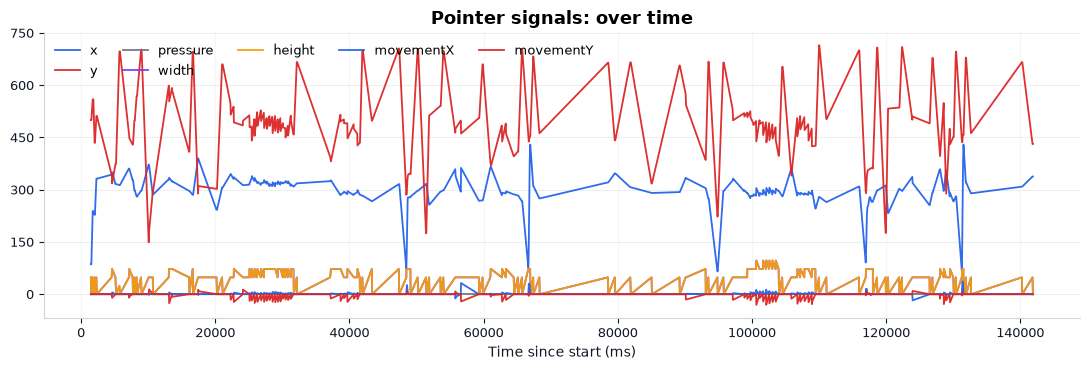

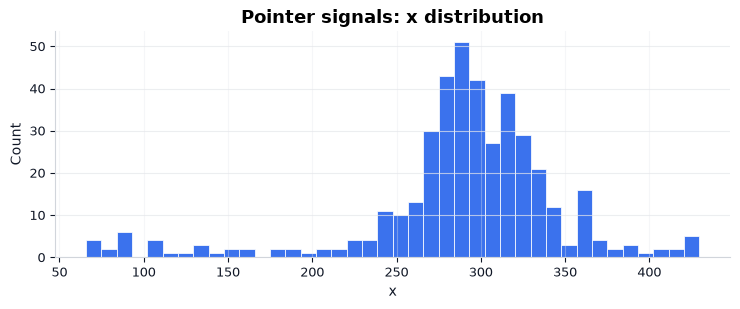

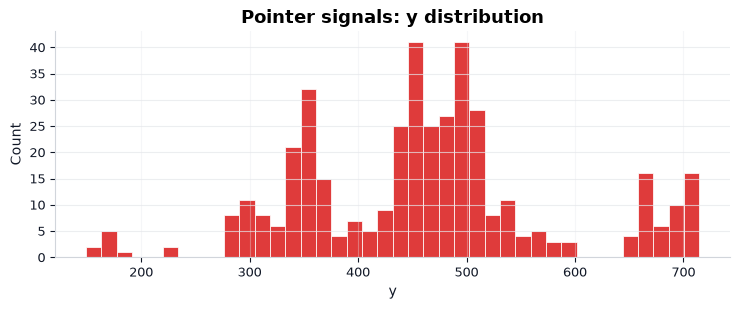

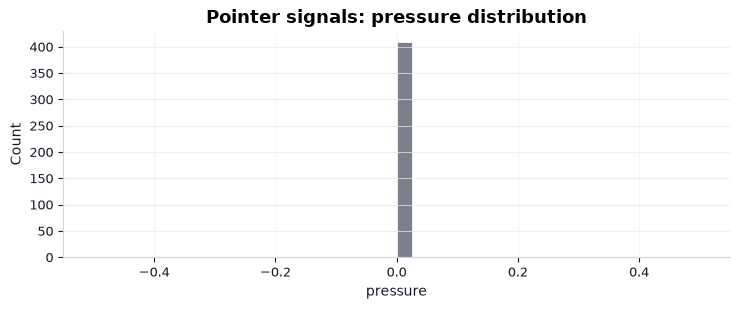

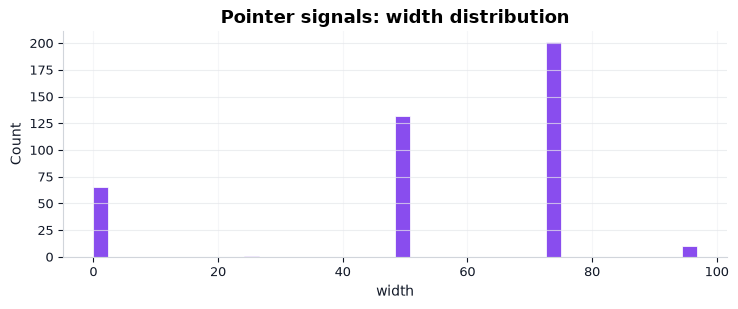

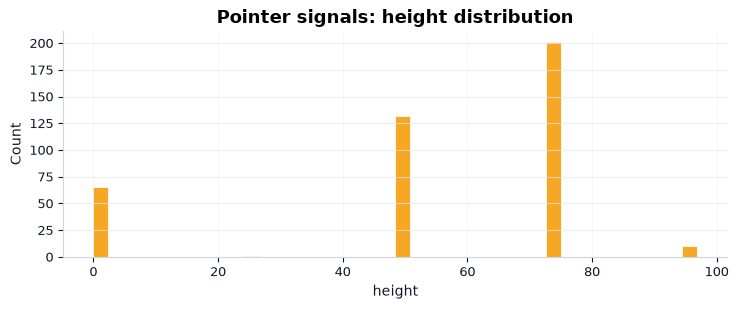

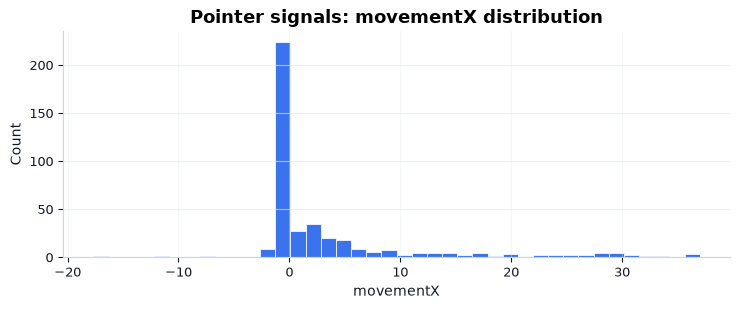

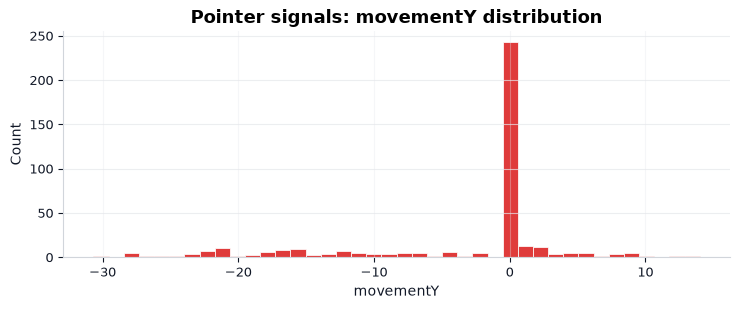

Touch signals: 1391 rows


,kind,tRelMs,x,y,force,radiusX,radiusY,rotationAngle,touchesCount
10,touchstart,1456,86.00,500.00,24.2078,24.2078,0.0,0.0,1.0
12,touchend,1530,86.00,500.00,0.0000,24.2078,0.0,0.0,0.0
15,touchstart,1735,238.67,559.67,24.2078,24.2078,0.0,0.0,1.0
17,touchend,1830,238.67,559.67,0.0000,24.2078,0.0,0.0,0.0
20,touchstart,2018,228.00,434.67,24.2078,24.2078,0.0,0.0,1.0
22,touchend,2063,228.00,434.67,0.0000,24.2078,0.0,0.0,0.0
25,touchstart,2285,331.67,512.00,24.2078,24.2078,0.0,0.0,1.0
27,touchend,2347,331.67,512.00,0.0000,24.2078,0.0,0.0,0.0
33,touchstart,4549,343.33,343.33,24.2078,24.2078,0.0,0.0,1.0
35,touchmove,4594,341.33,336.67,0.0000,24.2078,0.0,0.0,1.0


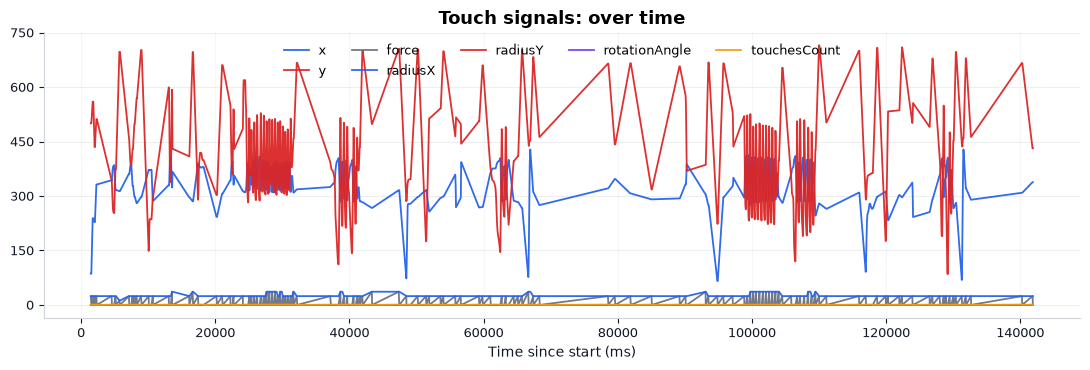

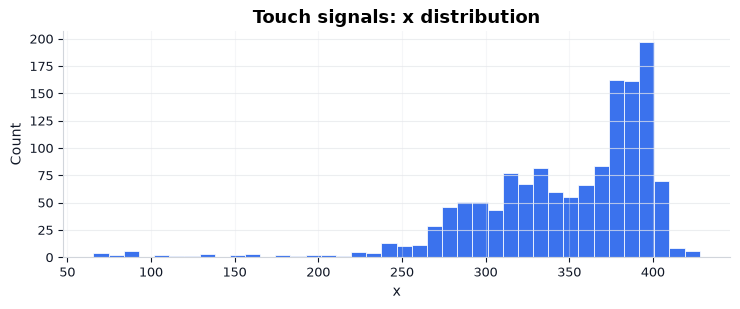

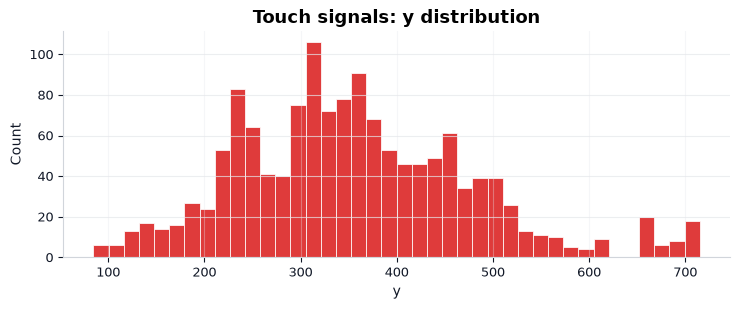

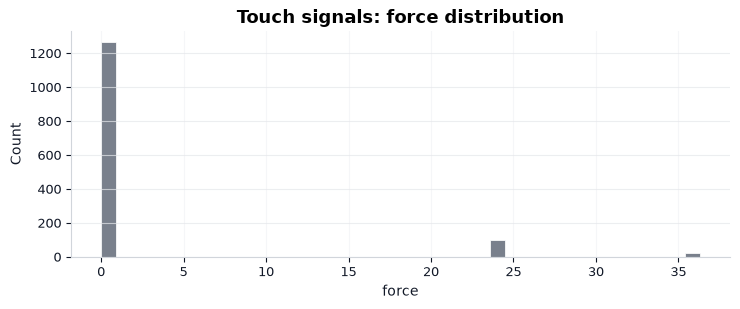

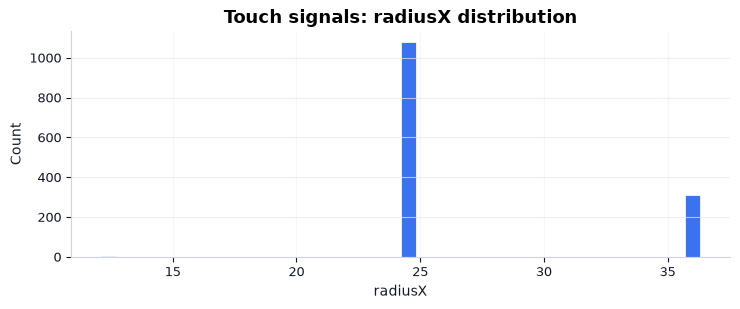

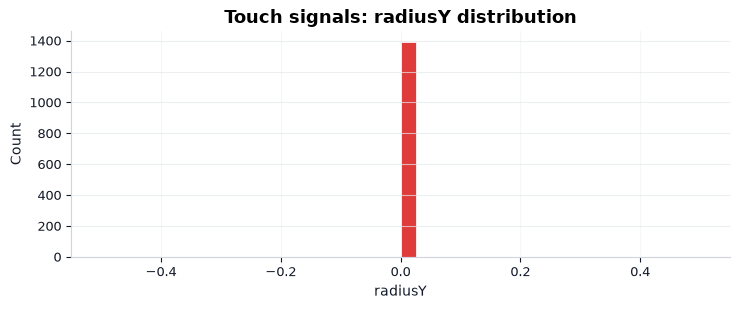

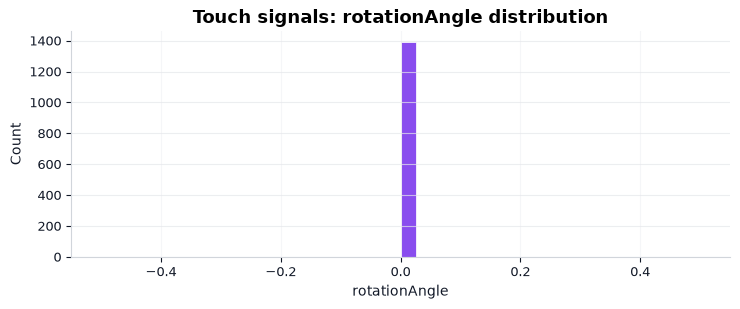

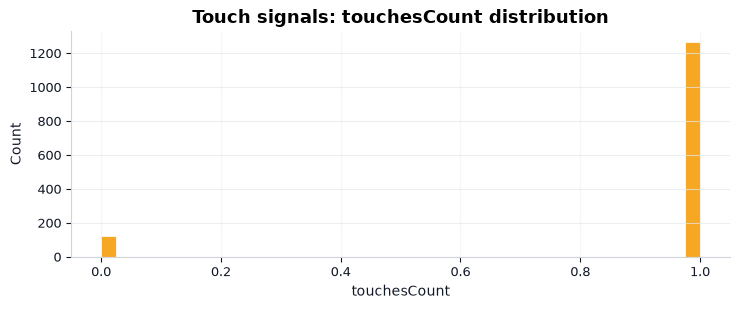

In [8]:
pointer = fdf[fdf["kind"].isin(["pointerdown", "pointermove", "pointerup"])].copy()
touch = fdf[fdf["kind"].isin(["touchstart", "touchmove", "touchend"])].copy()

plot_family(pointer, "Pointer signals", ["x", "y", "pressure", "width", "height", "movementX", "movementY"])
plot_family(touch, "Touch signals", ["x", "y", "force", "radiusX", "radiusY", "rotationAngle", "touchesCount"])

## Scroll and viewport

Scroll (vertical feeds): 673 rows


,kind,tRelMs,scrollTop,scrollLeft,scrollTopRatio
211,scroll,13153,32.0,0.0,0.01422
214,scroll,13185,106.0,0.0,0.04711
217,scroll,13219,165.0,0.0,0.07333
220,scroll,13252,196.0,0.0,0.08711
223,scroll,13285,210.0,0.0,0.09333
226,scroll,13319,215.0,0.0,0.09556
236,scroll,13584,250.0,0.0,0.11111
239,scroll,13618,329.0,0.0,0.14622
242,scroll,13651,388.0,0.0,0.17244
243,scroll,13684,425.0,0.0,0.18889


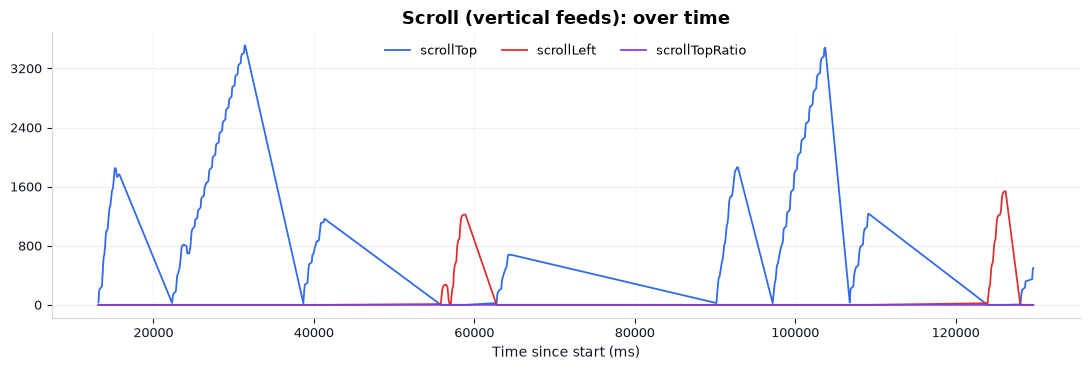

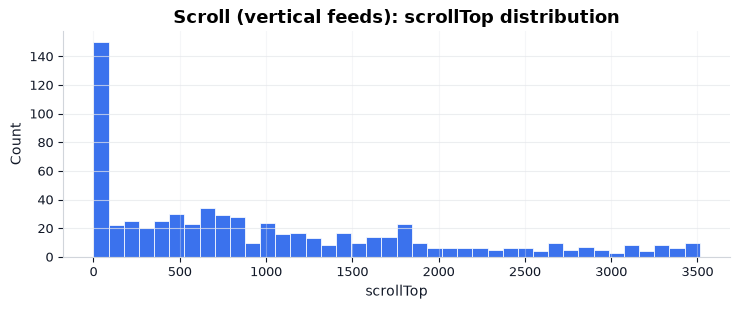

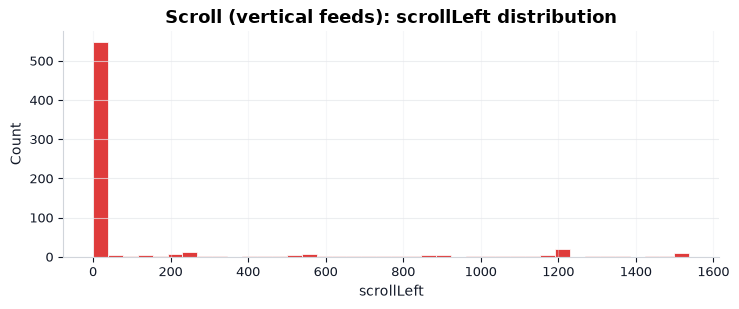

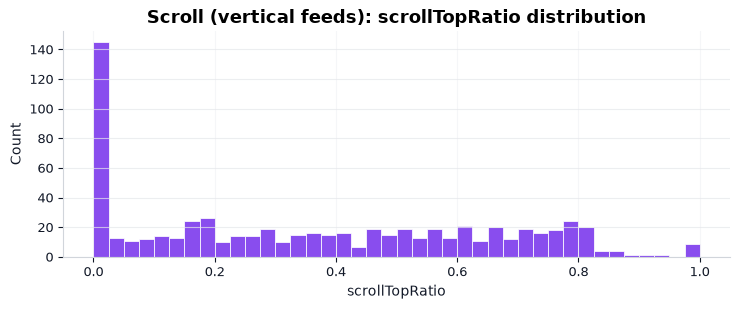

Carousel (horizontal) scroll: 247 rows


,kind,tRelMs,scrollLeft,maxScrollLeft
1401,carousel_scroll,55843,11.0,11.0
1403,carousel_scroll,55859,31.0,31.0
1406,carousel_scroll,55875,57.0,57.0
1409,carousel_scroll,55895,70.0,70.0
1411,carousel_scroll,55907,101.0,101.0
1413,carousel_scroll,55940,128.0,128.0
1414,carousel_scroll,55957,150.0,150.0
1416,carousel_scroll,55973,169.0,169.0
1417,carousel_scroll,55990,185.0,185.0
1419,carousel_scroll,56007,198.0,198.0


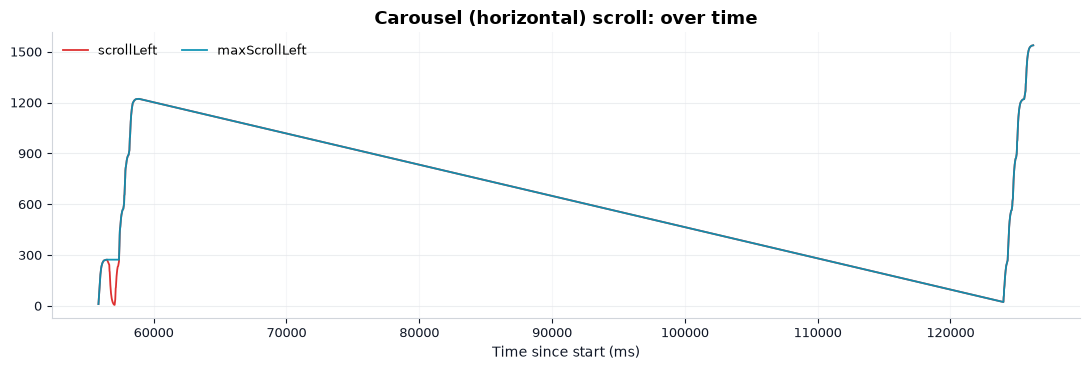

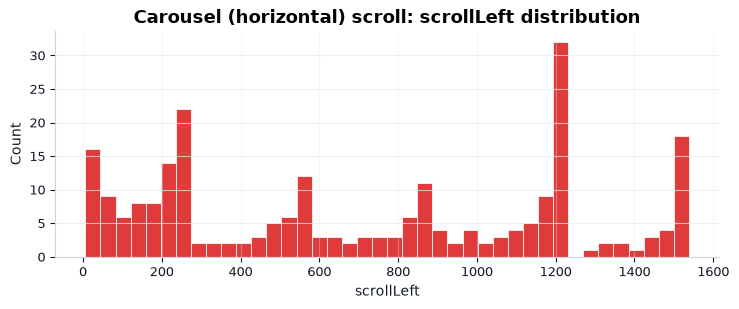

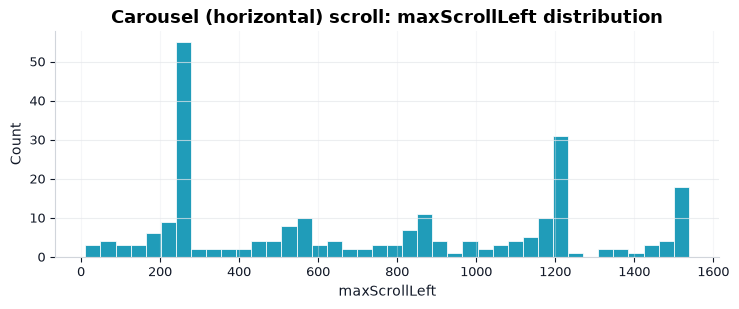

Viewport: 137 rows


,kind,tRelMs,viewportWidth,viewportHeight,scale
6,resize,64,NaN,NaN,NaN
7,visual_viewport_resize,64,430.0,775.0,1.0
42,resize,4660,NaN,NaN,NaN
43,visual_viewport_resize,4660,430.0,780.0,1.0
47,resize,4708,NaN,NaN,NaN
50,visual_viewport_resize,4723,430.0,789.0,1.0
55,visual_viewport_resize,4776,430.0,799.0,1.0
60,visual_viewport_resize,4828,430.0,809.0,1.0
67,visual_viewport_resize,4901,430.0,813.0,1.0
71,visual_viewport_resize,4992,430.0,815.0,1.0


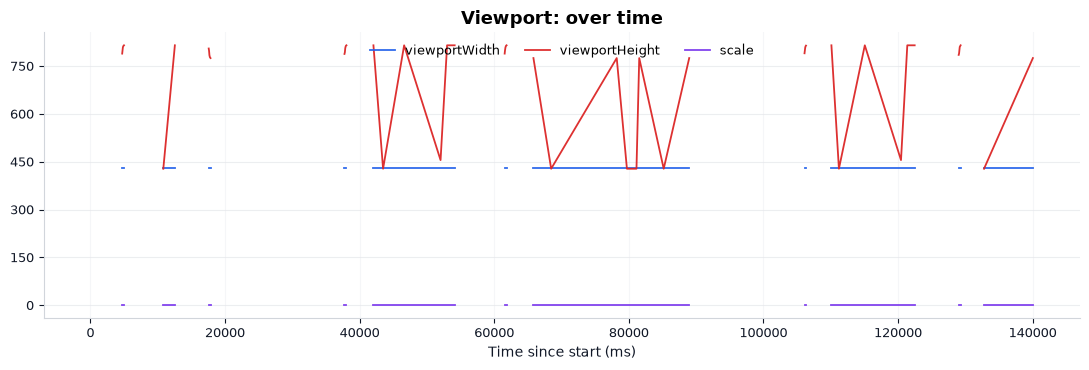

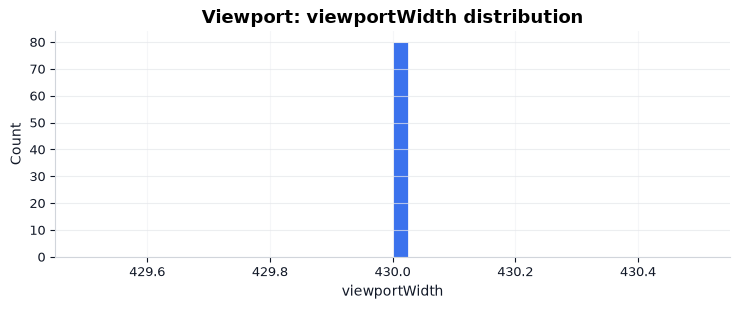

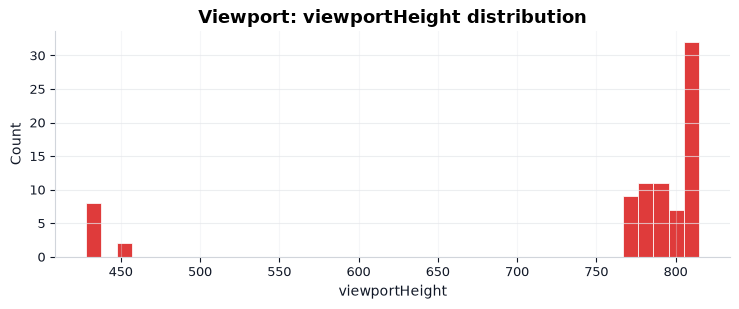

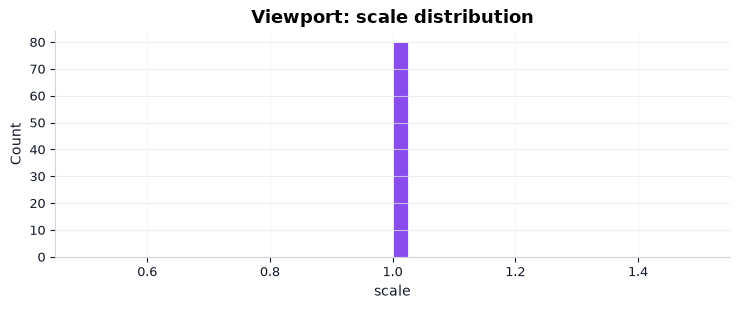

In [9]:
scroll = fdf[fdf["kind"] == "scroll"].copy()
carousel = fdf[fdf["kind"] == "carousel_scroll"].copy()
viewport = fdf[fdf["kind"].isin(["visual_viewport_resize", "visual_viewport_scroll", "resize"])].copy()

plot_family(scroll, "Scroll (vertical feeds)", ["scrollTop", "scrollLeft", "scrollTopRatio"])
plot_family(carousel, "Carousel (horizontal) scroll", ["scrollLeft", "maxScrollLeft"])
plot_family(viewport, "Viewport", ["viewportWidth", "viewportHeight", "scale"])

## Keyboard / input

Raw typed text is never stored; these are timing, length and class signals only.

Keyboard/input events: 504


,kind,count
0,keydown,126
1,beforeinput,126
2,input,126
3,keyup,126


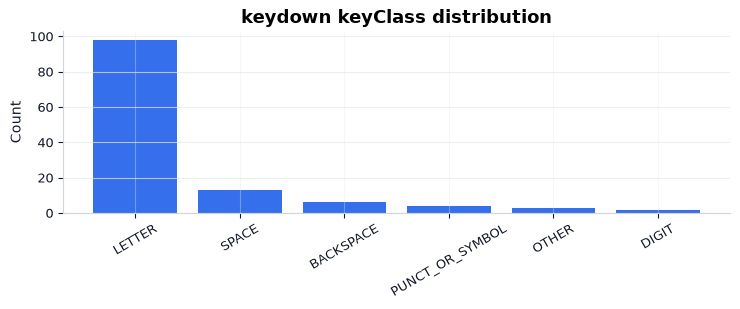

Keyboard/input numeric signals: 504 rows


,kind,tRelMs,valueLength,deltaLength,dataLength,selectionStart,selectionEnd
183,keydown,11552,0.0,NaN,NaN,0.0,0.0
184,beforeinput,11558,0.0,NaN,1.0,NaN,NaN
185,input,11561,1.0,1.0,NaN,1.0,1.0
186,keyup,11561,1.0,NaN,NaN,NaN,NaN
187,keydown,11731,1.0,NaN,NaN,1.0,1.0
188,beforeinput,11734,1.0,NaN,1.0,NaN,NaN
189,input,11736,2.0,1.0,NaN,2.0,2.0
190,keyup,11736,2.0,NaN,NaN,NaN,NaN
191,keydown,11856,2.0,NaN,NaN,2.0,2.0
192,beforeinput,11861,2.0,NaN,1.0,NaN,NaN


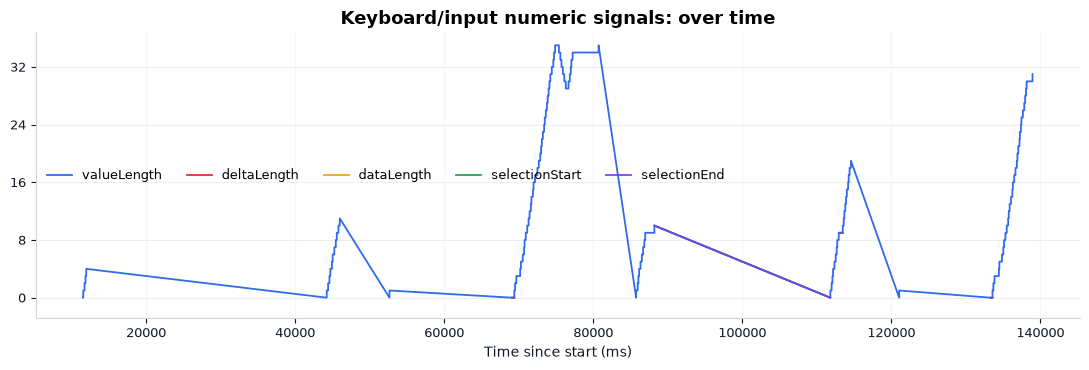

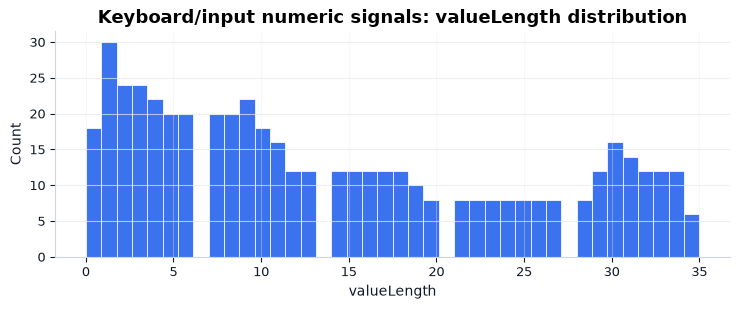

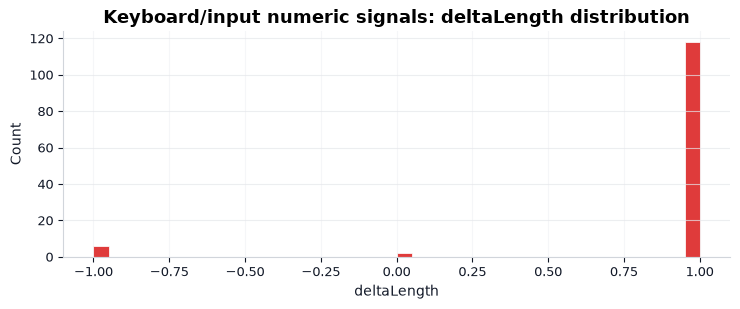

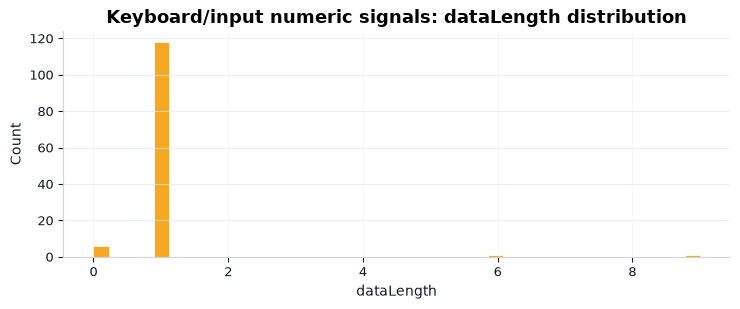

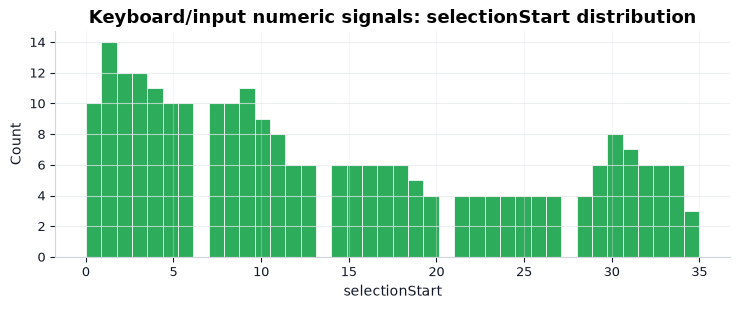

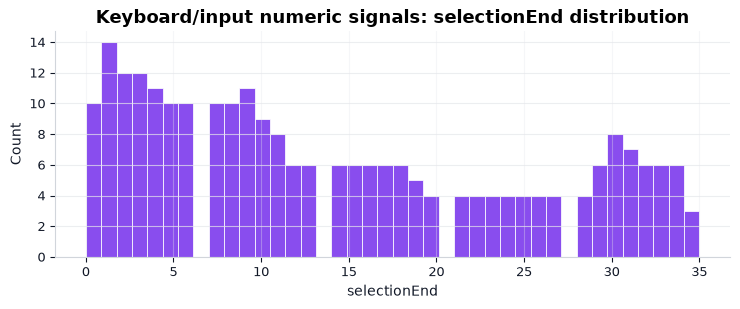

In [10]:
keyboard = fdf[fdf["kind"].isin(["keydown", "keyup", "beforeinput", "input", "select", "copy", "cut", "paste"])].copy()
print("Keyboard/input events:", len(keyboard))

if not keyboard.empty:
    kc = keyboard["kind"].value_counts().rename_axis("kind").reset_index(name="count")
    display(kc)
    kd = keyboard[keyboard["kind"] == "keydown"]
    if not kd.empty and "keyClass" in kd.columns:
        cls = kd["keyClass"].value_counts()
        fig, ax = plt.subplots(figsize=(7.5, 3.2))
        ax.bar(cls.index.astype(str), cls.values, color="#2563EB", alpha=0.92)
        ax.set_title("keydown keyClass distribution"); ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=30); polish_ax(ax)
        plt.tight_layout(); plt.show()
    plot_family(keyboard, "Keyboard/input numeric signals",
                ["valueLength", "deltaLength", "dataLength", "selectionStart", "selectionEnd"])

## Motion and orientation

Look for multi-second flat gaps (iOS pauses motion during typing/transitions) and for `alpha` drifting rather than holding a heading (relative orientation on iOS).

In [11]:
motion = fdf[fdf["kind"] == "devicemotion"].copy()
orientation = fdf[fdf["kind"] == "deviceorientation"].copy()

plot_family(motion, "Device acceleration", ["ax", "ay", "az"], show_table=False)
plot_family(motion, "Acceleration incl. gravity", ["agx", "agy", "agz"], show_table=False)
plot_family(motion, "Rotation rate", ["rotAlpha", "rotBeta", "rotGamma"], show_table=False)
plot_family(orientation, "Orientation", ["alpha", "beta", "gamma"], show_table=False)

Device acceleration: 0 rows
  no plottable columns found.
Acceleration incl. gravity: 0 rows
  no plottable columns found.
Rotation rate: 0 rows
  no plottable columns found.
Orientation: 0 rows
  no plottable columns found.


### Sensor sampling gaps (dropout check)

In [12]:
def gap_plot(df, title):
    if df.empty:
        print("Skipped (no data):", title); return
    d = df.sort_values("tRelMs")
    g = d["tRelMs"].diff()
    fig, ax = plt.subplots(figsize=(11, 3.0))
    ax.plot(d["tRelMs"], g, color="#DC2626", linewidth=1.0)
    ax.set_title(title); ax.set_xlabel("Time since start (ms)"); ax.set_ylabel("gap to prev (ms)")
    polish_ax(ax); plt.tight_layout(); plt.show()
    print("  median gap {:.0f} ms | max gap {:.0f} ms".format(g.median(), g.max()))

gap_plot(motion, "devicemotion inter-sample gap")
gap_plot(orientation, "deviceorientation inter-sample gap")

Skipped (no data): devicemotion inter-sample gap
Skipped (no data): deviceorientation inter-sample gap


## Gesture summaries (discrete)

These are one-off summary events (a handful per session), so a table is more useful than a plot.

In [13]:
gest_kinds = ["gesture_drag_start", "gesture_drag_end", "pot_drag_release",
              "approval_swipe_release", "card_swipe_summary"]
gest = fdf[fdf["kind"].isin(gest_kinds)].copy()
if gest.empty:
    print("No gesture summary events in this session.")
else:
    show = ["kind", "tRelMs", "taskId", "pointerType", "samples", "distancePx", "durationMs",
            "swipeRatio", "releasedValue", "targetValue", "correctRelease",
            "selectedCard", "targetCardSelected", "maxScrollLeftRatio", "approved"]
    show = [c for c in show if c in gest.columns]
    display(gest[show].dropna(axis=1, how="all").reset_index(drop=True))

,kind,tRelMs,taskId,pointerType,samples,distancePx,durationMs,swipeRatio,releasedValue,targetValue,correctRelease,selectedCard,targetCardSelected,maxScrollLeftRatio,approved
0,gesture_drag_start,48488,pots_drag_amount_01,touch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,pot_drag_release,49115,pots_drag_amount_01,NaN,NaN,NaN,627.0,NaN,9,9,True,NaN,NaN,NaN,NaN
2,gesture_drag_end,49115,pots_drag_amount_01,touch,26.0,220.660,627.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,card_swipe_summary,59359,insights_swipe_cards_01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,shopping,True,0.571,NaN
4,gesture_drag_start,66668,secure_approval_01,touch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,approval_swipe_release,66963,secure_approval_01,NaN,NaN,NaN,295.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,True
6,gesture_drag_end,66963,secure_approval_01,touch,18.0,354.054,295.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,gesture_drag_start,116966,pots_drag_amount_02,touch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,pot_drag_release,118028,pots_drag_amount_02,NaN,NaN,NaN,1062.0,NaN,8,8,True,NaN,NaN,NaN,NaN
9,gesture_drag_end,118028,pots_drag_amount_02,touch,54.0,220.646,1062.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Per-task overview & session structure

,sessionKey,taskId,taskType,taskArea,taskIndex,startedAtMs,completedAtMs,durationMs,completed,evidence
0,pG5G4MS_s3,unlock_code_01,code,secure,0,25,2550,2525,True,"{'inputLength': 4, 'codeCorrect': True, 'corrections': 0, 'completedWithCorrectCode': True}"
1,pG5G4MS_s3,home_balance_check_01,tap_account,home,1,2550,5797,3247,True,"{'accountReviewed': True, 'selectedAccount': 'current'}"
2,pG5G4MS_s3,home_explore_cards_01,home_explore,home,2,5797,9027,3230,True,"{'exploredAccounts': ['current', 'bills', 'travel'], 'exploredCount': 3, 'allAccountsExplored': True}"
3,pG5G4MS_s3,activity_search_01,typing_search,activity,3,9027,16701,7674,True,"{'inputLength': 4, 'targetLength': 4, 'deltaLengthLast': 1, 'corrections': 0, 'completedLength': True, 'exactMatch': True, 'exactCaseSensitiveMatch': False,..."
4,pG5G4MS_s3,activity_filter_review_01,activity_filter,activity,4,16701,21114,4413,True,"{'filterSelected': 'Groceries', 'correctFilter': True}"
5,pG5G4MS_s3,activity_scroll_select_01,transaction_feed,activity,5,21114,32218,11104,True,"{'feedMaxScrollTop': 3513, 'feedMaxScrollTopRatio': 0.8075862068965517, 'selectedTarget': True, 'selectedMerchant': 'Lidl', 'selectedWhen': 'Last month', 's..."
6,pG5G4MS_s3,transaction_category_01,categorise,activity,6,32219,41991,9772,True,"{'categoryMaxScrollTop': 1163, 'categoryMaxScrollTopRatio': 0.824822695035461, 'categorySelected': True, 'category': 'Groceries', 'correctCategory': True}"
7,pG5G4MS_s3,transaction_note_01,guided_note,activity,7,41991,47436,5445,True,"{'inputLength': 11, 'targetLength': 11, 'deltaLengthLast': 1, 'corrections': 0, 'completedLength': True, 'exactMatch': True, 'exactCaseSensitiveMatch': True..."
8,pG5G4MS_s3,pots_drag_amount_01,pot_drag,pots,8,47437,50250,2813,True,"{'currentRatio': 0.7273809523809522, 'currentValue': '9', 'targetValue': '9', 'withinTolerance': True, 'dragSamples': 26, 'dragDistancePx': 220.659654615672..."
9,pG5G4MS_s3,pots_transfer_01,pots_transfer,pots,9,50250,54063,3813,True,"{'potSelected': 'travel', 'travelPotSelected': True, 'inputLength': 1, 'targetLength': 1, 'deltaLengthLast': 1, 'corrections': 0, 'completedLength': True, '..."


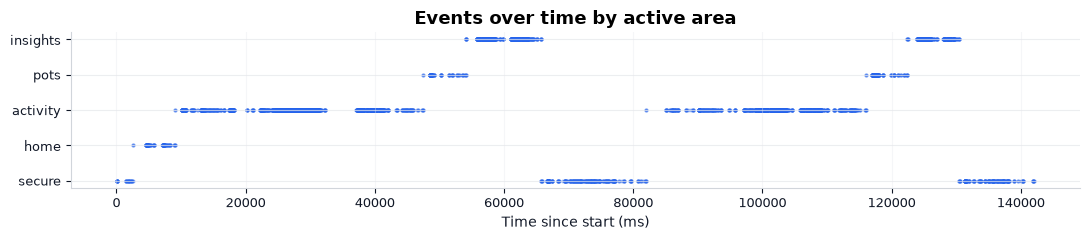

In [14]:
foc_tasks = tasks_df[tasks_df["sessionKey"] == FOCUS_SESSION] if not tasks_df.empty else tasks_df
if not foc_tasks.empty:
    display(foc_tasks.reset_index(drop=True))

# event timeline coloured by active area -> shows how the session was navigated
if not fdf.empty and "activeArea" in fdf.columns:
    areas = [a for a in fdf["activeArea"].dropna().unique()]
    ymap = {a: i for i, a in enumerate(areas)}
    fig, ax = plt.subplots(figsize=(11, max(2.5, len(areas) * 0.4)))
    ax.scatter(fdf["tRelMs"], fdf["activeArea"].map(ymap), s=4, alpha=0.35, color="#2563EB")
    ax.set_yticks(range(len(areas))); ax.set_yticklabels(areas)
    ax.set_title("Events over time by active area"); ax.set_xlabel("Time since start (ms)")
    polish_ax(ax); plt.tight_layout(); plt.show()

## Quick auto-observations

A few computed hints to point the eye; not a substitute for looking at the graphs.

In [15]:
if field_df.empty:
    print("No data loaded.")
else:
    dead = field_df[field_df["allZeroish"]][["kind", "field"]]
    print("Constant-zero (dead) fields:")
    print("  " + (", ".join("{}.{}".format(r.kind, r.field) for r in dead.itertuples()) if len(dead) else "none"))
    o = fdf[fdf["kind"] == "deviceorientation"]
    if not o.empty and "absolute" in o.columns:
        print("deviceorientation.absolute non-null:", int(o["absolute"].notna().sum()), "/", len(o), "(0 => relative-only, normal on iOS)")
    pm = int((fdf["kind"] == "pointermove").sum()); tm = int((fdf["kind"] == "touchmove").sum())
    print("pointermove vs touchmove:", pm, "vs", tm, "(touch dominates on iOS)")
    m = fdf[fdf["kind"] == "devicemotion"].sort_values("tRelMs")
    if len(m) > 2:
        g = m["tRelMs"].diff()
        print("devicemotion: {} samples, first at {:.0f} ms, max gap {:.0f} ms".format(len(m), m["tRelMs"].iloc[0], g.max()))

Constant-zero (dead) fields:
  account_card_selected.contentSetIndex, beforeinput.isComposing, keydown.repeat, keydown.ctrlKey, keydown.altKey, keydown.metaKey, passcode_digit_tap.contentSetIndex, pointercancel.buttons, pointercancel.x, pointercancel.y, pointercancel.xNorm, pointercancel.yNorm, pointercancel.pageX, pointercancel.pageY, pointercancel.screenX, pointercancel.screenY, pointercancel.movementX, pointercancel.movementY, pointercancel.pressure, pointercancel.tiltX, pointercancel.tiltY, pointercancel.twist, pointercancel.coalescedCount, pointerdown.button, pointerdown.movementX, pointerdown.movementY, pointerdown.pressure, pointerdown.tiltX, pointerdown.tiltY, pointerdown.twist, pointerdown.coalescedCount, pointermove.pressure, pointermove.tiltX, pointermove.tiltY, pointermove.twist, pointerup.button, pointerup.buttons, pointerup.movementX, pointerup.movementY, pointerup.pressure, pointerup.width, pointerup.height, pointerup.tiltX, pointerup.tiltY, pointerup.twist, pointerup.co